# 04 — Analysis (reads `shared/`, computes nothing new except §8)
Deep-dive on one scenario's books: executive scorecard, cohort, claims, validation, N-regime comparison, telematics tiers, EV split, Monte Carlo, verdicts. Ideas ported from `voltvision_all.ipynb` Part 2 (§1–§9), generalized to N regimes — every table/figure loops the discovered regime list, no hardcoded trio.

Needs `shared/sim_<SC>` + `shared/priced_<SC>_*`: run `01` + `02`, or `python run_all.py --scenarios <SC>`.

In [1]:
import copy, glob, os, sys
ROOT = os.path.abspath('')
if ROOT not in sys.path: sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from voltvision import CFG, SCEN, N_YEARS, REGIMES, COLS
from voltvision import ensure_core_methods, RateCard
from voltvision import compare_all, summary, lr, lr_by, rho, retained_lr, reg_color, reg_label
from voltvision import gen, simulate, quote, io
%matplotlib inline

# --- Which scenario to dissect; regimes discovered from shared/ files ---
SC = "MIX"
seen = []
for f in sorted(glob.glob(os.path.join('shared', f'priced_{SC}_*.*'))):
    stem = os.path.basename(f).split('.')[0]
    r = stem.split(f'priced_{SC}_', 1)[1]
    if r not in seen:
        seen.append(r)
# Core regimes first (stable order), custom ones after, discovery order.
REGIMES_RUN = [m for m in REGIMES if m in seen] + [m for m in seen if m not in REGIMES]
books = {m: io.load_priced(SC, m) for m in REGIMES_RUN}
raw = io.load_sim(SC)
print(f'{SC}: {len(raw)} rows, regimes = {REGIMES_RUN}')


MIX: 84041 rows, regimes = ['tariff', 'glm', 'telem']


## §1 Executive summary — one scorecard row per regime (N rows, N bars)

,Regime,LR (%),Retained LR (15%),Prem-count rho,Avg prem (RM)
0,Tariff,74.45,80.04,0.361,1515.0
1,GLM,61.47,56.68,0.640,1835.0
2,GLM+Telematics,61.52,56.09,0.640,1834.0


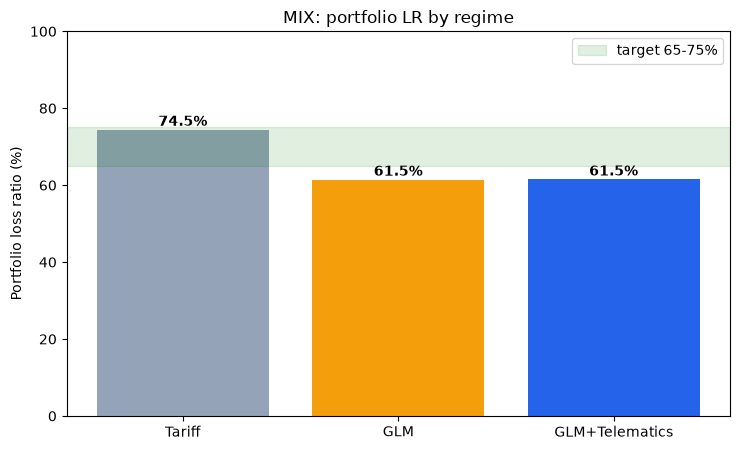

In [2]:
# Scorecard shared with the desk and runner: LR, retained LR, alignment, premium.
tab = compare_all(books)
display(tab)
fig, ax = plt.subplots(figsize=(max(7.5, 2.2 * len(tab)), 4.6))
bars = ax.bar(tab['Regime'], tab['LR (%)'], color=[reg_color(m) for m in REGIMES_RUN])
for b, v in zip(bars, tab['LR (%)']):
    ax.text(b.get_x() + b.get_width() / 2, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
ax.axhspan(65, 75, color='green', alpha=0.12, label='target 65-75%')
ax.set_ylim(0, max(100, tab['LR (%)'].max() + 10))
ax.set_ylabel('Portfolio loss ratio (%)'); ax.set_title(f'{SC}: portfolio LR by regime')
ax.legend(); plt.tight_layout(); plt.show()


## §2 Portfolio & cohort — what the book looks like, how it evolves

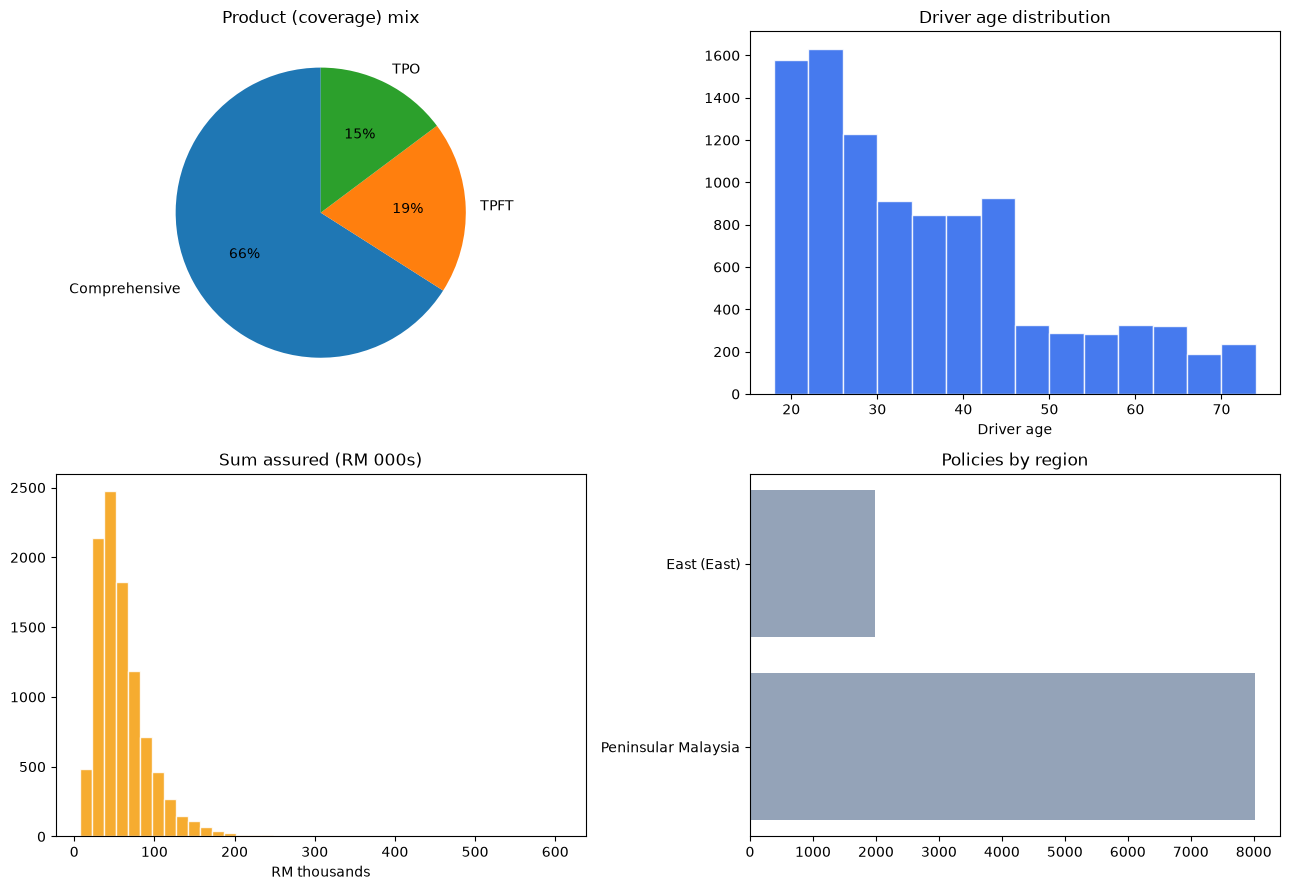

vehicle mix at inception: {'ICE': 0.897, 'EV': 0.103}


Year,Active policies,Claims,Freq,Avg NCD priced,Retention
2026,10000,1844,16.4%,24.4%,87.6%
2027,13765,2486,16.4%,29.4%,88.3%
2028,17151,3147,16.6%,31.7%,88.5%
2029,20182,3630,16.4%,33.3%,88.9%
2030,22943,4121,16.3%,34.3%,89.1%


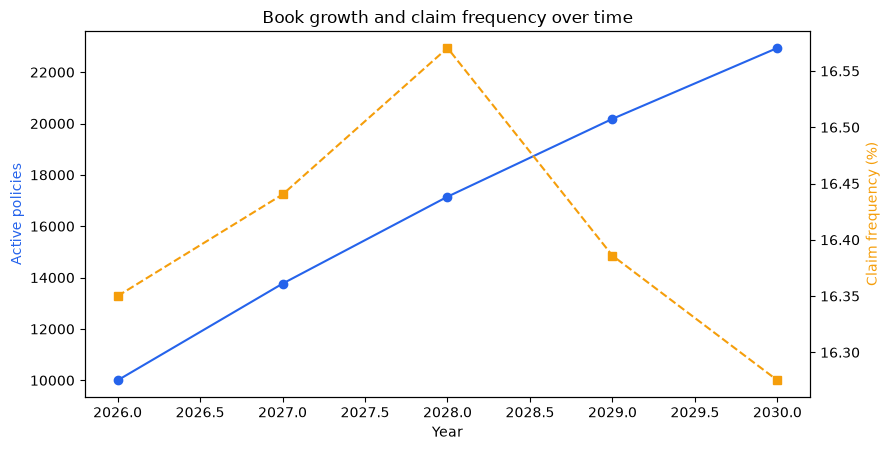

In [3]:
# Inception snapshot (first SIM_YEAR): product mix, driver ages, sums assured, regions.
d0 = raw[raw.SIM_YEAR == raw.SIM_YEAR.min()]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
cov_pct = d0['COVERAGE_TYPE'].value_counts(normalize=True) * 100
axes[0, 0].pie(cov_pct.values, labels=cov_pct.index, autopct='%.0f%%', startangle=90)
axes[0, 0].set_title('Product (coverage) mix')
axes[0, 1].hist(d0['DRIVER_AGE'], bins=range(18, 76, 4), color='#2563eb', edgecolor='white', alpha=0.85)
axes[0, 1].set_title('Driver age distribution'); axes[0, 1].set_xlabel('Driver age')
axes[1, 0].hist(d0['SUM_ASSURED'] / 1000, bins=40, color='#f59e0b', edgecolor='white', alpha=0.85)
axes[1, 0].set_title('Sum assured (RM 000s)'); axes[1, 0].set_xlabel('RM thousands')
reg = d0['REGION'].str.replace(' Malaysia (Sabah, Sawarak & Labuan)', ' (East)', regex=False).value_counts()
axes[1, 1].barh(reg.index, reg.values, color='#94a3b8')
axes[1, 1].set_title('Policies by region')
plt.tight_layout(); plt.show()
print('vehicle mix at inception:', d0['VEHICLE_TYPE'].value_counts(normalize=True).round(3).to_dict())

# Cohort evolution: growth, frequency, priced NCD, retention per year.
rows = []
for y in sorted(raw.SIM_YEAR.unique()):
    yd = raw[raw.SIM_YEAR == y]
    rows.append({'Year': y, 'Active policies': len(yd), 'Claims': int(yd['CLAIM_COUNT'].sum()),
                 'Freq': yd['CLAIM_OCCURRED'].mean(), 'Avg NCD priced': yd['NCD_LEVEL_PRICED'].mean(),
                 'Retention': yd['RENEWED'].mean()})
cs = pd.DataFrame(rows)
display(cs.style.format({'Freq': '{:.1%}', 'Avg NCD priced': '{:.1%}', 'Retention': '{:.1%}'}).hide(axis='index'))
fig, ax1 = plt.subplots(figsize=(9, 4.6))
ax1.plot(cs.Year, cs['Active policies'], '-o', color='#2563eb', label='Active policies')
ax1.set_xlabel('Year'); ax1.set_ylabel('Active policies', color='#2563eb')
ax2 = ax1.twinx()
ax2.plot(cs.Year, cs['Freq'] * 100, '--s', color='#f59e0b', label='Claim frequency %')
ax2.set_ylabel('Claim frequency (%)', color='#f59e0b')
ax1.set_title('Book growth and claim frequency over time')
plt.tight_layout(); plt.show()


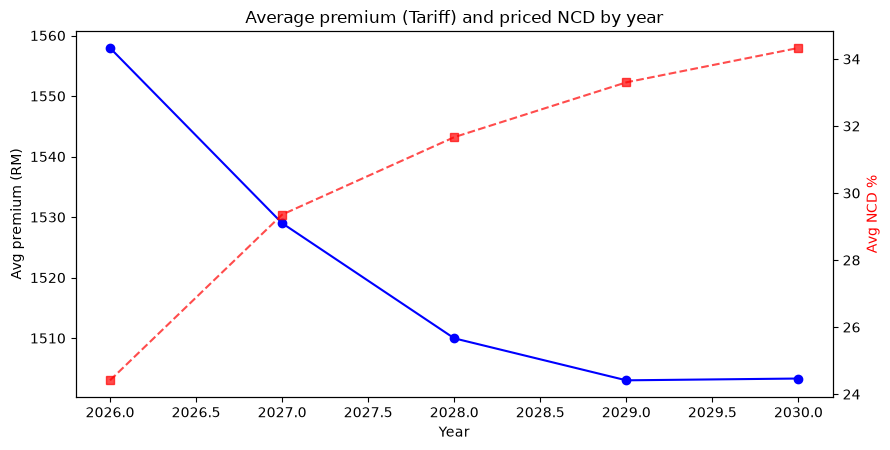

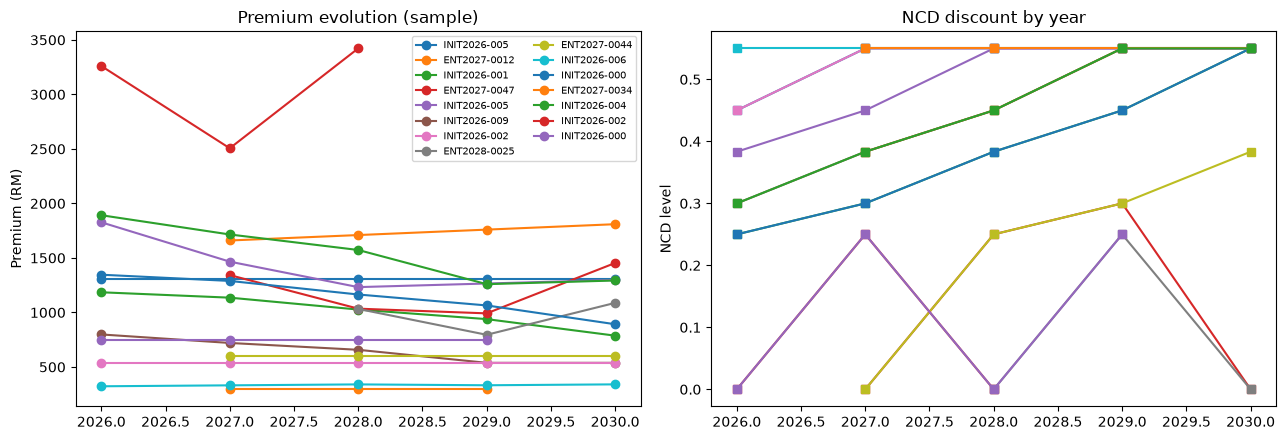

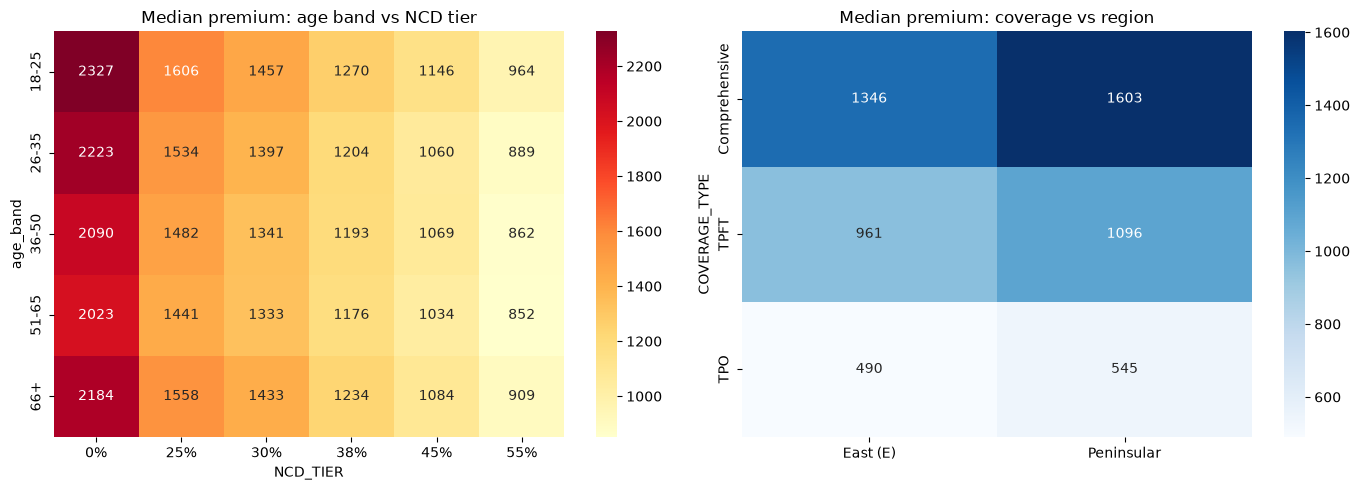

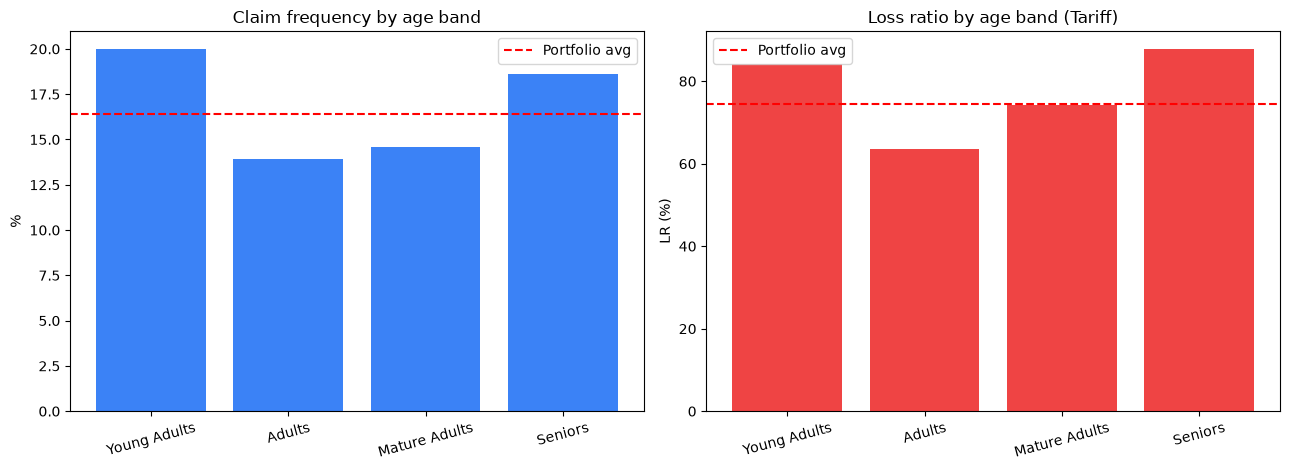

In [4]:
# Premium pressure vs loyalty: tariff avg premium (twin axis: priced NCD).
# First regime's book stands in — claims are identical across regimes.
ref = books[REGIMES_RUN[0]]
fig, ax1 = plt.subplots(figsize=(9, 4.6))
ax1.plot(sorted(ref.SIM_YEAR.unique()),
         ref.groupby('SIM_YEAR')['FINAL_PREMIUM_SST'].mean().values, 'b-o', label='Avg premium')
ax1.set_xlabel('Year'); ax1.set_ylabel('Avg premium (RM)')
ax2 = ax1.twinx()
ax2.plot(sorted(raw.SIM_YEAR.unique()),
         raw.groupby('SIM_YEAR')['NCD_LEVEL_PRICED'].mean().values * 100, 'r--s', alpha=0.7, label='Avg NCD %')
ax2.set_ylabel('Avg NCD %', color='red')
ax1.set_title(f'Average premium ({reg_label(REGIMES_RUN[0])}) and priced NCD by year')
plt.tight_layout(); plt.show()

# Sample policy trails: 15 policies with 3+ years, premium + NCD paths.
ny = raw.groupby('POLID')['SIM_YEAR'].nunique()
picks = list(np.random.RandomState(42).choice(ny[ny >= 3].index, size=15, replace=False))
sel = ref[ref.POLID.isin(picks)]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for pid in picks:
    p = sel[sel.POLID == pid].sort_values('SIM_YEAR')
    axes[0].plot(p.SIM_YEAR, p.FINAL_PREMIUM_SST, marker='o', label=str(pid)[:12])
    axes[1].plot(p.SIM_YEAR, p.NCD_LEVEL, marker='s')
axes[0].set_title('Premium evolution (sample)'); axes[0].set_ylabel('Premium (RM)')
axes[0].legend(fontsize=7, ncol=2)
axes[1].set_title('NCD discount by year'); axes[1].set_ylabel('NCD level')
plt.tight_layout(); plt.show()

# Median premium surfaces: age band x NCD tier, coverage x region.
fd = ref.copy()
fd['NCD_TIER'] = fd.NCD_LEVEL.map({0.0: '0%', 0.25: '25%', 0.30: '30%', 0.3833: '38%', 0.45: '45%', 0.55: '55%'})
fd['age_band'] = pd.cut(fd.DRIVER_AGE, bins=[17, 25, 35, 50, 65, 100],
                        labels=['18-25', '26-35', '36-50', '51-65', '66+'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(fd.groupby(['age_band', 'NCD_TIER'], observed=True)['FINAL_PREMIUM_SST'].median().unstack(),
            annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Median premium: age band vs NCD tier')
p2 = fd.groupby(['COVERAGE_TYPE', 'REGION'], observed=True)['FINAL_PREMIUM_SST'].median().unstack()
p2.columns = [c.replace(' Malaysia (Sabah, Sawarak & Labuan)', ' (E)').replace(' Malaysia', '') for c in p2.columns]
sns.heatmap(p2, annot=True, fmt='.0f', cmap='Blues', ax=axes[1])
axes[1].set_title('Median premium: coverage vs region')
plt.tight_layout(); plt.show()

# U-shaped age risk: frequency + LR per driver band vs portfolio average.
cats = ['Young Adults', 'Adults', 'Mature Adults', 'Seniors']
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
freq_age = ref.groupby('DRIVER_AGE_CAT', observed=True)['CLAIM_OCCURRED'].mean().reindex(cats) * 100
axes[0].bar(freq_age.index, freq_age.values, color='#3b82f6')
axes[0].axhline(ref['CLAIM_OCCURRED'].mean() * 100, ls='--', color='red', label='Portfolio avg')
axes[0].set_title('Claim frequency by age band'); axes[0].set_ylabel('%')
axes[0].legend(); axes[0].tick_params(axis='x', rotation=15)
lr_age = pd.Series({c: lr(ref[ref.DRIVER_AGE_CAT == c]) for c in cats})
axes[1].bar(lr_age.index, lr_age.values, color='#ef4444')
axes[1].axhline(lr(ref), ls='--', color='red', label='Portfolio avg')
axes[1].set_title(f'Loss ratio by age band ({reg_label(REGIMES_RUN[0])})'); axes[1].set_ylabel('LR (%)')
axes[1].legend(); axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()


## §3 Claims profile — frequency, severity, peril mix, LR by coverage (regime-independent counts, LR per first regime)

Coverage,Policies,Freq,Claims,Sev/claim (RM),LR (%)
Comprehensive,54400,19.4%,11795,"5,210",62.300000
TPFT,16839,12.0%,2174,"10,081",103.000000
TPO,12802,9.4%,1259,"9,090",153.600000


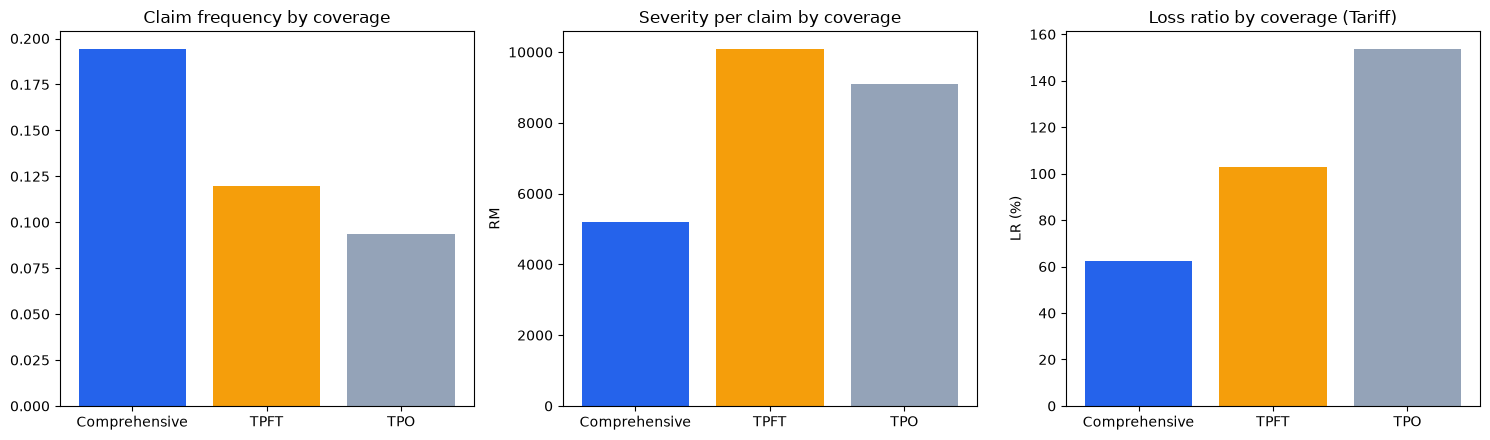

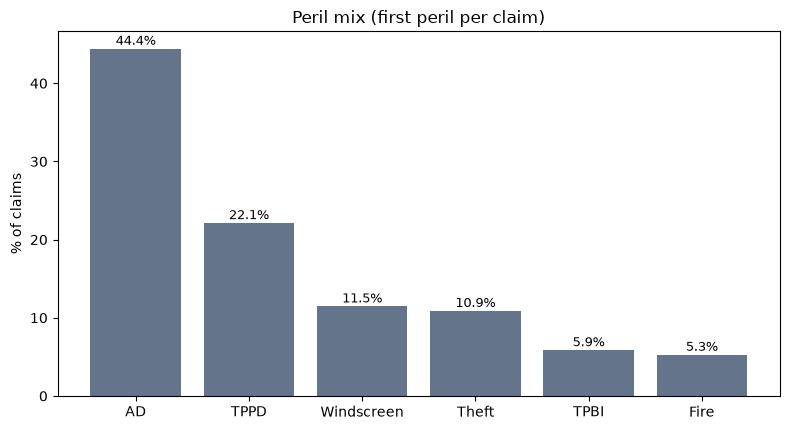

mean severity per first peril (RM):
pf
TPBI          24380.0
Theft         14033.0
Fire           8762.0
TPPD           5681.0
AD             4483.0
Windscreen     1886.0


In [5]:
# Claims don't depend on pricing — one table from raw, LR from the first regime.
rows = []
for cov in ('Comprehensive', 'TPFT', 'TPO'):
    sub = raw[raw.COVERAGE_TYPE == cov]
    n = sub['CLAIM_COUNT'].sum()
    rows.append({'Coverage': cov, 'Policies': len(sub), 'Freq': sub['CLAIM_OCCURRED'].mean(),
                 'Claims': int(n), 'Sev/claim (RM)': round(sub['CLAIM_AMOUNT'].sum() / n, 0) if n else 0,
                 'LR (%)': round(lr(books[REGIMES_RUN[0]][books[REGIMES_RUN[0]].COVERAGE_TYPE == cov]), 1)})
cdf = pd.DataFrame(rows)
display(cdf.style.format({'Freq': '{:.1%}', 'Sev/claim (RM)': '{:,.0f}'}).hide(axis='index'))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].bar(cdf['Coverage'], cdf['Freq'], color=['#2563eb', '#f59e0b', '#94a3b8'])
axes[0].set_title('Claim frequency by coverage')
axes[1].bar(cdf['Coverage'], cdf['Sev/claim (RM)'], color=['#2563eb', '#f59e0b', '#94a3b8'])
axes[1].set_title('Severity per claim by coverage'); axes[1].set_ylabel('RM')
axes[2].bar(cdf['Coverage'], cdf['LR (%)'], color=['#2563eb', '#f59e0b', '#94a3b8'])
axes[2].set_title(f"Loss ratio by coverage ({reg_label(REGIMES_RUN[0])})"); axes[2].set_ylabel('LR (%)')
plt.tight_layout(); plt.show()

# Peril mix: first peril per policy-year tells the story (multi-claim joins split on '/').
peril_first = raw[raw.CLAIM_AMOUNT > 0]['CLAIM_PERIL'].str.split('/').str[0]
mix = peril_first.value_counts(normalize=True).sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.bar(mix.index, mix.values, color='#64748b')
ax.set_title('Peril mix (first peril per claim)'); ax.set_ylabel('% of claims')
for x, v in zip(mix.index, mix.values):
    ax.text(x, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout(); plt.show()
sev_peril = raw[raw.CLAIM_AMOUNT > 0].assign(pf=peril_first).groupby('pf')['CLAIM_AMOUNT'].mean().sort_values(ascending=False)
print('mean severity per first peril (RM):')
print(sev_peril.round(0).to_string())


## §4 Validation — PASS/FAIL sanity checks + distribution tests (model trust)

In [6]:
# Cheap invariants first: any FAIL here stops trust in everything downstream.
res, checks = raw, []
add = lambda name, ok, detail='': checks.append({'Check': name, 'Pass': 'PASS' if ok else 'FAIL', 'Detail': detail})
add('Claim frequency within 10-20%', 0.10 <= res['CLAIM_OCCURRED'].mean() <= 0.20, f"{res['CLAIM_OCCURRED'].mean():.1%}")
add('TPO claim freq < Comprehensive',
    res.loc[res.COVERAGE_TYPE == 'TPO', 'CLAIM_OCCURRED'].mean() < res.loc[res.COVERAGE_TYPE == 'Comprehensive', 'CLAIM_OCCURRED'].mean())
add('Claims reset NCD to 0', (res.loc[res.CLAIM_OCCURRED, 'NCD_YEARS'] == 0).mean() >= 0.99)
add('Claim-free years increment NCD', (res.loc[~res.CLAIM_OCCURRED, 'NCD_YEARS'] >= 1).mean() >= 0.99)
add('No nulls in key fields', res[['CLAIM_COUNT', 'CLAIM_AMOUNT', 'CLAIM_LAMBDA', 'NCD_LEVEL', 'RENEWED']].isnull().sum().sum() == 0)
add('Mean driver age rises across years',
    res.groupby('SIM_YEAR')['DRIVER_AGE'].mean().iloc[-1] > res.groupby('SIM_YEAR')['DRIVER_AGE'].mean().iloc[0])
ev = res[res.CLAIM_PERIL.str.split('/').str[0].isin(['AD', 'Theft', 'Fire'])]
add('EV severity > ICE on own-damage perils',
    ev.loc[ev.VEHICLE_TYPE == 'EV', 'CLAIM_AMOUNT'].mean() > ev.loc[ev.VEHICLE_TYPE == 'ICE', 'CLAIM_AMOUNT'].mean())
t = pd.DataFrame(checks)
display(t)
print(f"core checks: {(t.Pass == 'PASS').sum()}/{len(t)} passed")
print('retention claimed vs clean:', res.groupby('CLAIM_OCCURRED')['RENEWED'].mean().round(3).to_dict())

# Distribution shape: log-premium ~ normal (mixture accepted), counts ~ Poisson,
# severity ~ gamma per coverage. KS < 0.20 passes (mixtures never fit perfectly).
from scipy.stats import kstest, norm, gamma as gamma_dist
prem = books[REGIMES_RUN[0]]['FINAL_PREMIUM_SST']
lp = np.log(prem)
ks_lp, _ = kstest(lp, norm(loc=lp.mean(), scale=lp.std()).cdf)
print(f'log-premium KS={ks_lp:.3f} (pass < 0.20) | skew={lp.skew():.3f}')
vm = res.CLAIM_COUNT.var() / res.CLAIM_COUNT.mean()
print(f'claim count var/mean={vm:.3f} (Poisson ~= 1; heterogeneity inflates)')
for cov in ['Comprehensive', 'TPFT', 'TPO']:
    s = res[(res.COVERAGE_TYPE == cov) & (res.CLAIM_AMOUNT > 0)].CLAIM_AMOUNT
    if len(s) > 30:
        sh, lo, sc = gamma_dist.fit(s, floc=0)
        ks, _ = kstest(s, gamma_dist(a=sh, loc=lo, scale=sc).cdf)
        print(f'{cov}: gamma shape={sh:.2f} KS={ks:.3f} mean=RM{s.mean():,.0f}')


,Check,Pass,Detail
0,Claim frequency within 10-20%,PASS,16.4%
1,TPO claim freq < Comprehensive,PASS,
2,Claims reset NCD to 0,PASS,
3,Claim-free years increment NCD,PASS,
4,No nulls in key fields,PASS,
5,Mean driver age rises across years,PASS,
6,EV severity > ICE on own-damage perils,PASS,


core checks: 7/7 passed
retention claimed vs clean: {False: 0.928, True: 0.675}
log-premium KS=0.015 (pass < 0.20) | skew=0.015
claim count var/mean=1.025 (Poisson ~= 1; heterogeneity inflates)
Comprehensive: gamma shape=0.54 KS=0.055 mean=RM5,816
TPFT: gamma shape=0.55 KS=0.033 mean=RM10,871
TPO: gamma shape=0.42 KS=0.070 mean=RM9,537


## §5 Pricing comparison — N regimes, one scorecard, effectiveness checks

,Regime,LR (%),Retained LR (15%),Prem-count rho,Avg prem (RM)
0,Tariff,74.45,80.04,0.361,1515.0
1,GLM,61.47,56.68,0.640,1835.0
2,GLM+Telematics,61.52,56.09,0.640,1834.0


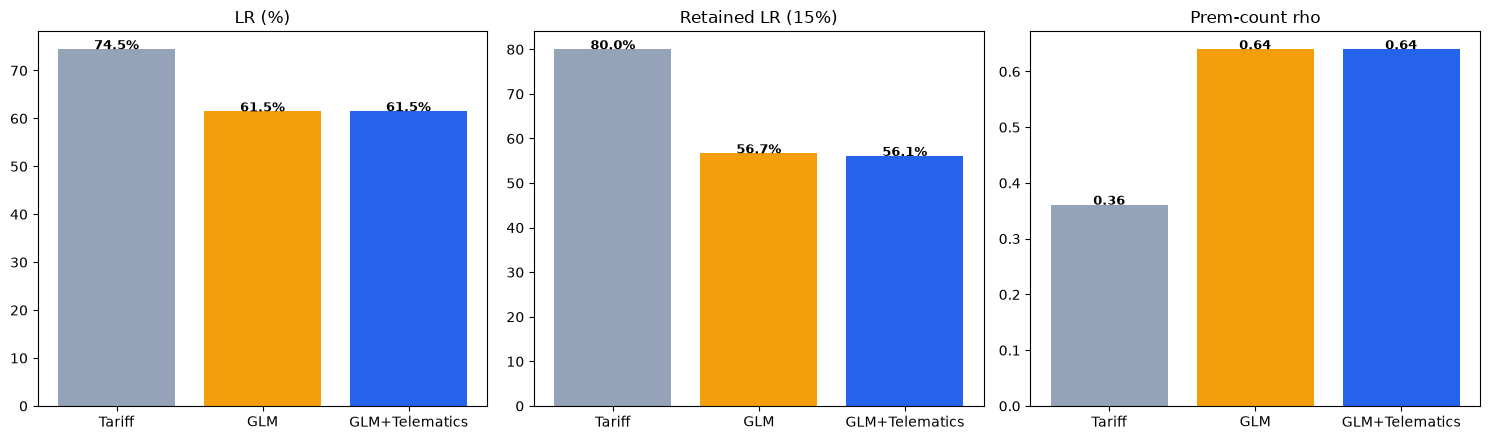

In [7]:
# Same scorecard as §1, plus one panel per metric — bars scale to N regimes.
pcd = compare_all(books)
display(pcd)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, fmt in zip(axes, ['LR (%)', f"Retained LR ({0.15:.0%})", 'Prem-count rho'], ['{:.1f}%', '{:.1f}%', '{:.2f}']):
    bars = ax.bar(pcd['Regime'], pcd[col], color=[reg_color(m) for m in REGIMES_RUN])
    for b, v in zip(bars, pcd[col]):
        ax.text(b.get_x() + b.get_width() / 2, v, fmt.format(v), ha='center', fontweight='bold', fontsize=9)
    ax.set_title(col)
plt.tight_layout(); plt.show()


In [8]:
# Effectiveness checks (N-safe): risk signals separate claimants; the best
# risk-priced regime beats tariff on LR and retained LR; alignment reported.
ck, b0 = [], books[REGIMES_RUN[0]]
c13 = lambda name, ok, detail='': ck.append({'Check': name, 'Pass': 'PASS' if ok else 'FAIL', 'Detail': detail})
c13('Behavior risk higher for claimants',
    b0.loc[b0.CLAIM_OCCURRED, 'BEHAVIOR_RISK'].mean() > b0.loc[~b0.CLAIM_OCCURRED, 'BEHAVIOR_RISK'].mean())
c13('Telematics score lower for claimants',
    b0.loc[b0.CLAIM_OCCURRED, 'telematics_score'].mean() < b0.loc[~b0.CLAIM_OCCURRED, 'telematics_score'].mean())
lrs = {m: lr(b) for m, b in books.items()}
best = min(lrs, key=lrs.get)
c13(f'Best regime ({reg_label(best)}) LR < {reg_label(REGIMES_RUN[0])} LR',
    lrs[best] < lrs[REGIMES_RUN[0]], f"{lrs[best]:.1f}% vs {lrs[REGIMES_RUN[0]]:.1f}%")
rls = {m: retained_lr(b) for m, b in books.items()}
c13('Best retained LR < first-regime retained LR', min(rls.values()) < rls[REGIMES_RUN[0]])
rhos = {m: rho(b) for m, b in books.items()}
c13(f"Strongest alignment: {reg_label(max(rhos, key=rhos.get))} rho={max(rhos.values()):.3f}", True)
t = pd.DataFrame(ck)
display(t)
print(f'effectiveness: {(t.Pass == "PASS").sum()}/{len(t)} passed')


,Check,Pass,Detail
0,Behavior risk higher for claimants,PASS,
1,Telematics score lower for claimants,PASS,
2,Best regime (GLM) LR < Tariff LR,PASS,61.5% vs 74.4%
3,Best retained LR < first-regime retained LR,PASS,
4,Strongest alignment: GLM+Telematics rho=0.640,PASS,


effectiveness: 5/5 passed


## §5b Cross-scenario comparison — the review table
Same regimes across books: tariff on ICE-only, combined, EV-only; the ML
regimes on EV-only. Rows: TPO loss ratio, average loss ratio, premium
lower/upper bound (min-max across policy-years), average premium.
Missing columns mean the scenario hasn't been simulated yet — run
`python run_all.py --scenarios ICE,EV,MIX` (or `01`/`02`) first.

In [9]:
# Build the review table from whatever scenarios are on disk.
# Column order fixed by the pairs list; anything missing is listed.
pairs = [('ICE', 'tariff', 'Tariff ICE ONLY'),
         ('MIX', 'tariff', 'Tariff EV and ICE combined'),
         ('EV', 'tariff', 'Tariff EV ONLY'),
         ('EV', 'glm', 'GLM EV ONLY'),
         ('EV', 'telem', 'GLM + Telematics EV ONLY')]
rows, missing = {}, []
for sc, rg, label in pairs:
    try:
        b = io.load_priced(sc, rg)
    except FileNotFoundError:
        missing.append(f'{sc}/{rg}')
        continue
    rows[label] = {
        'TPO Loss Ratio (%)': round(lr(b[b.COVERAGE_TYPE == 'TPO']), 1),
        'Average Loss Ratio (%)': round(lr(b), 1),
        'Premium lower-upper bound (RM)':
            f"{b.FINAL_PREMIUM_SST.min():,.0f} - {b.FINAL_PREMIUM_SST.max():,.0f}",
        'Average premium (RM)': round(b.FINAL_PREMIUM_SST.mean(), 0)}
if missing:
    print('columns missing — simulate & price first:', missing)
cross = pd.DataFrame(rows).T
display(cross)


,TPO Loss Ratio (%),Average Loss Ratio (%),Premium lower-upper bound (RM),Average premium (RM)
Tariff ICE ONLY,143.3,73.0,"162 - 14,833",1442.0
Tariff EV and ICE combined,153.6,74.4,"202 - 18,401",1515.0
Tariff EV ONLY,123.2,70.7,"205 - 23,516",2158.0
GLM EV ONLY,64.8,61.6,"46 - 20,740",2478.0
GLM + Telematics EV ONLY,64.8,61.6,"43 - 24,291",2478.0


## §5c Leak check — in-sample vs out-of-sample training
Default pricing now trains on a separate historical book (seed 42,
2021–2025); the priced book spans 2026–2030. The legacy path
(`train_book_seed=None`) trains on the priced book itself. The gap shows
how optimistic the old self-trained numbers were.

In [ ]:
# Same book, same claims: only the training source differs.
ensure_core_methods()  # load 02x CALC cells for live quoting
card_out = RateCard.from_cfg(CFG)                       # default: historical book (seed 42)
card_in = RateCard.from_cfg(CFG, train_book_seed=None)  # legacy: trains on the priced book
rows = []
for m in REGIMES_RUN:
    b_in, b_out = quote(raw, m, card_in), quote(raw, m, card_out)
    rows.append({'Regime': reg_label(m),
                 'In-sample LR (%)': round(lr(b_in), 2),
                 'Out-of-sample LR (%)': round(lr(b_out), 2),
                 'Leak (pp)': round(lr(b_in) - lr(b_out), 2),
                 'In rho': round(rho(b_in), 4), 'Out rho': round(rho(b_out), 4),
                 'Avg prem in/out (RM)': f"{b_in.FINAL_PREMIUM_SST.mean():,.0f} / {b_out.FINAL_PREMIUM_SST.mean():,.0f}"})
display(pd.DataFrame(rows))
print('negative gap = old self-trained default understated LR (in-sample optimism); rho barely moves.')


## §6 Telematics tiers — premium and LR per score band, one column-pair per regime

,Tariff prem,GLM prem,GLM+Telematics prem,Tariff LR,GLM LR,GLM+Telematics LR
Telematics tier,,,,,,
<50 High risk,1639.0,2418.0,2784.0,106.0,71.9,62.4
50-70,1583.0,2139.0,2278.0,89.5,66.2,62.2
70-85,1516.0,1857.0,1860.0,76.4,62.4,62.3
85-100 Safe,1487.0,1674.0,1605.0,64.3,57.1,59.6


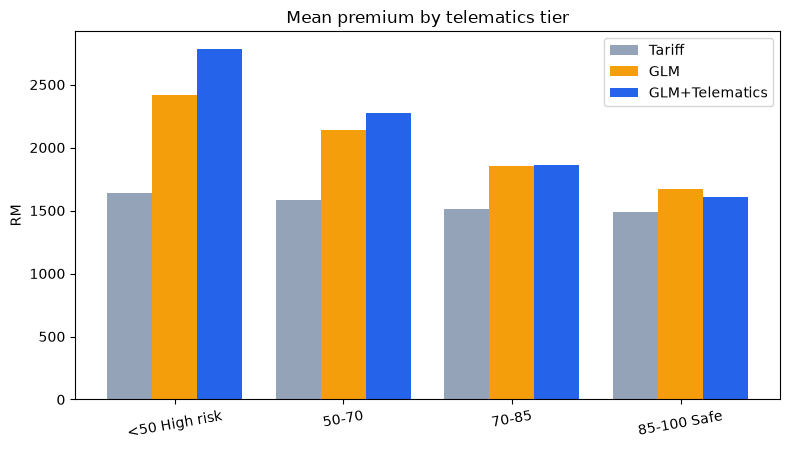

In [10]:
# Score bands from safe (85-100) to high-risk (<50): does dearer telematics
# premium actually sit where the losses are, per regime?
def tier_table(b):
    d = b.copy()
    d['tier'] = pd.cut(d['telematics_score'], bins=[0, 50, 70, 85, 100],
                       labels=['<50 High risk', '50-70', '70-85', '85-100 Safe'])
    g = d.groupby('tier', observed=False).agg(n=('POLID', 'size'), mean_prem=('FINAL_PREMIUM_SST', 'mean'),
                                              claims=('CLAIM_AMOUNT', 'sum'), prem_sum=('FINAL_PREMIUM_SST', 'sum'))
    g['lr'] = g['claims'] / g['prem_sum'] * 100
    return g[['n', 'mean_prem', 'lr']]

tiers = {m: tier_table(b) for m, b in books.items()}
tab = pd.DataFrame({f'{reg_label(m)} prem': tiers[m]['mean_prem'].round(0) for m in REGIMES_RUN})
tab = tab.join(pd.DataFrame({f'{reg_label(m)} LR': tiers[m]['lr'].round(1) for m in REGIMES_RUN}))
tab.index.name = 'Telematics tier'
display(tab)
x = np.arange(len(tab))
fig, ax = plt.subplots(figsize=(max(8, 2.5 * len(REGIMES_RUN)), 4.6))
w = 0.8 / len(REGIMES_RUN)
for i, m in enumerate(REGIMES_RUN):
    ax.bar(x + (i - (len(REGIMES_RUN) - 1) / 2) * w, tiers[m]['mean_prem'], w,
           label=reg_label(m), color=reg_color(m))
ax.set_xticks(x); ax.set_xticklabels(tab.index, rotation=10)
ax.set_title('Mean premium by telematics tier'); ax.set_ylabel('RM'); ax.legend()
plt.tight_layout(); plt.show()


## §7 EV vs ICE — share, frequency, severity, LR per year (first regime prices; counts identical)

,EV share,EV freq,EV sev/claim,EV LR,EV prem,ICE share,ICE freq,ICE sev/claim,ICE LR,ICE prem
SIM_YEAR,,,,,,,,,,
2026,10.3%,17.9%,"9,023",84.1%,"2,194",89.7%,16.2%,"5,514",67.6%,"1,485"
2027,10.1%,16.0%,"7,547",61.7%,"2,152",89.9%,16.5%,"5,900",73.2%,"1,459"
2028,10.0%,17.7%,"7,669",70.1%,"2,113",90.0%,16.4%,"6,226",78.7%,"1,443"
2029,10.3%,19.2%,"8,812",86.8%,"2,142",89.7%,16.1%,"5,893",72.7%,"1,430"
2030,10.2%,16.0%,"8,601",72.7%,"2,116",89.8%,16.3%,"6,075",76.2%,"1,434"


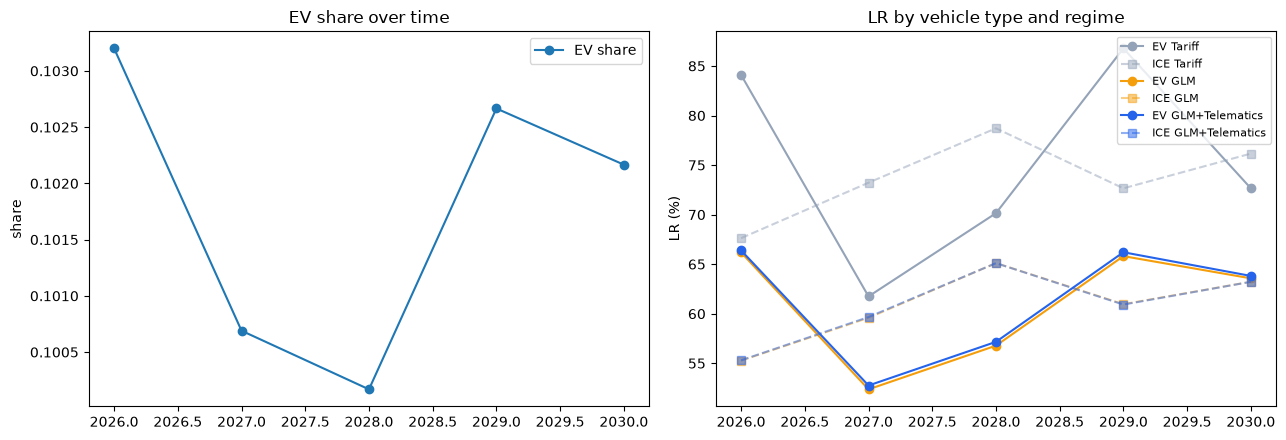

In [11]:
# EV costs more to assure and repair: check the book prices that in.
# Adoption-ramp scenarios need the EV-ramp engine TODO — out of scope here.
def evice(g):
    out = {}
    for nm in ('EV', 'ICE'):
        s = g[g.VEHICLE_TYPE == nm]
        n = s.CLAIM_COUNT.sum()
        out[nm + ' share'] = len(s) / len(g)
        out[nm + ' freq'] = s.CLAIM_OCCURRED.mean()
        out[nm + ' sev/claim'] = s.CLAIM_AMOUNT.sum() / n if n else float('nan')
        out[nm + ' LR'] = s.CLAIM_AMOUNT.sum() / s.FINAL_PREMIUM_SST.sum() if s.FINAL_PREMIUM_SST.sum() else float('nan')
        out[nm + ' prem'] = s.FINAL_PREMIUM_SST.mean()
    return pd.Series(out)

ev_df = books[REGIMES_RUN[0]].groupby('SIM_YEAR').apply(evice)
display(ev_df.style.format({'EV share': '{:.1%}', 'ICE share': '{:.1%}', 'EV freq': '{:.1%}',
                            'ICE freq': '{:.1%}', 'EV sev/claim': '{:,.0f}', 'ICE sev/claim': '{:,.0f}',
                            'EV LR': '{:.1%}', 'ICE LR': '{:.1%}',
                            'EV prem': '{:,.0f}', 'ICE prem': '{:,.0f}'}))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(ev_df.index, ev_df['EV share'], '-o', label='EV share')
axes[0].set_title('EV share over time'); axes[0].set_ylabel('share'); axes[0].legend()
for m in REGIMES_RUN:
    e = books[m].groupby('SIM_YEAR').apply(
        lambda g: pd.Series({'EV': g[g.VEHICLE_TYPE == 'EV'].CLAIM_AMOUNT.sum() / g[g.VEHICLE_TYPE == 'EV'].FINAL_PREMIUM_SST.sum(),
                              'ICE': g[g.VEHICLE_TYPE == 'ICE'].CLAIM_AMOUNT.sum() / g[g.VEHICLE_TYPE == 'ICE'].FINAL_PREMIUM_SST.sum()}))
    axes[1].plot(e.index, e['EV'] * 100, '-o', label=f"EV {reg_label(m)}", color=reg_color(m))
    axes[1].plot(e.index, e['ICE'] * 100, '--s', label=f"ICE {reg_label(m)}", color=reg_color(m), alpha=0.5)
axes[1].set_title('LR by vehicle type and regime'); axes[1].set_ylabel('LR (%)'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## §8 Monte Carlo — seeds × frequency scenarios × N regimes (uncertainty around baseline)

tariff calc registered
glm calc registered
telem calc registered


mean    p5   p95  P_LR_gt_75
scen      regime                                      
Base      GLM             60.3  58.8  61.5         0.0
          GLM+Telematics  60.3  58.8  61.5         0.0
          Tariff          74.7  65.2  81.7        66.7
High-freq GLM             60.1  59.2  61.1         0.0
          GLM+Telematics  60.2  59.2  61.1         0.0
          Tariff          91.3  85.0  95.1       100.0

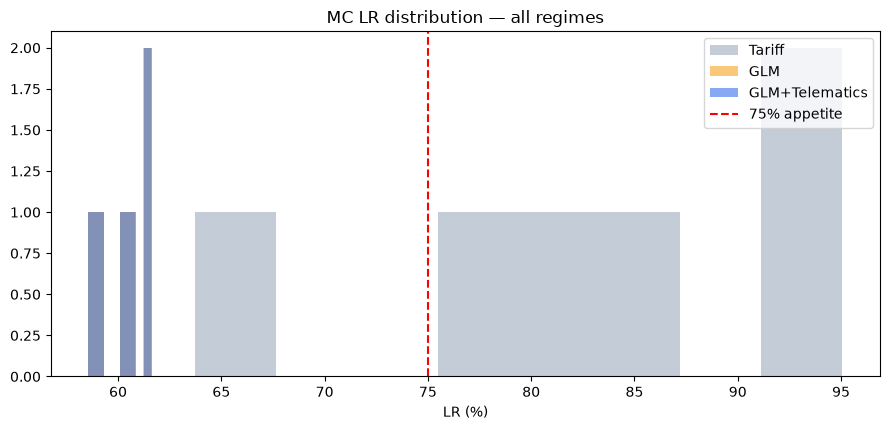

In [12]:
# Small by default (MC_N=2000, 2 years): shape of uncertainty, not the full bill.
# Set MC_FULL=True for n=10000 × 5 years (slow: ~15 runs of the full engine).
import itertools
MC_FULL, MC_SEEDS = False, (0, 1, 2)
mc_cfg = copy.deepcopy(CFG)
if not MC_FULL:
    mc_cfg['n'] = 2000
mc_years = N_YEARS if MC_FULL else 2
ensure_core_methods()
card = RateCard.from_cfg(mc_cfg)
rows = []
for ov, s, m in itertools.product([None, {'claim_frequency_base': -1.80}], MC_SEEDS, REGIMES_RUN):
    c = copy.deepcopy(mc_cfg)
    if ov:
        c.update(ov)
    b = simulate(gen(c, SCEN[SC], c['seed']), c, SCEN[SC], seed=s, n_years=mc_years, verbose=False)
    q = quote(b, m, RateCard.from_cfg(c))
    rows.append({'scen': 'High-freq' if ov else 'Base', 'seed': s, 'regime': reg_label(m),
                 'lr': q['CLAIM_AMOUNT'].sum() / q['FINAL_PREMIUM_SST'].sum()})
mc = pd.DataFrame(rows)
tab = mc.groupby(['scen', 'regime'])['lr'].agg(mean='mean', p5=lambda x: x.quantile(.05),
    p95=lambda x: x.quantile(.95), P_LR_gt_75=lambda x: (x > 0.75).mean())
display((tab * 100).round(1))
fig, ax = plt.subplots(figsize=(9, 4.4))
for m in REGIMES_RUN:
    ax.hist(mc[mc.regime == reg_label(m)]['lr'] * 100, bins=8, alpha=0.55,
            label=reg_label(m), color=reg_color(m))
ax.axvline(75, color='red', ls='--', label='75% appetite')
ax.legend(); ax.set_xlabel('LR (%)'); ax.set_title('MC LR distribution — all regimes')
plt.tight_layout(); plt.show()


## §9 Verdicts — numbers first, words second (all values computed above, none hardcoded)

In [13]:
# Each line prints a computed fact: re-run the book, the verdicts follow.
lrs = {m: lr(b) for m, b in books.items()}
best = min(lrs, key=lrs.get)
tpo = {m: books[m][books[m].COVERAGE_TYPE == 'TPO'] for m in REGIMES_RUN}
print(f"1. Portfolio LR ({SC}): " + "; ".join(f"{reg_label(m)} {v:.1f}%" for m, v in lrs.items()))
print(f"2. Best regime is {reg_label(best)} at {lrs[best]:.1f}% (target band 65-75%).")
print(f"3. Tariff TPO LR is {lr(tpo[REGIMES_RUN[0]]):.1f}% — the flat TPO rate underprices; "
      "recalibrate tpo_sa_pct/tpo_loading on the RateCard.")
print(f"4. Strongest alignment: {reg_label(max(books, key=lambda m: rho(books[m])))} "+
      f"rho={max(rho(b) for b in books.values()):.3f}.")
print(f"5. Shedding the dearest 15% moves {reg_label(best)} LR to {retained_lr(books[best]):.1f}%.")
print("6. EV adoption scenarios wait on the EV-ramp engine TODO (entrants use base mix today).")


1. Portfolio LR (MIX): Tariff 74.4%; GLM 61.5%; GLM+Telematics 61.5%
2. Best regime is GLM at 61.5% (target band 65-75%).
3. Tariff TPO LR is 153.6% — the flat TPO rate underprices; recalibrate tpo_sa_pct/tpo_loading on the RateCard.
4. Strongest alignment: GLM+Telematics rho=0.640.
5. Shedding the dearest 15% moves GLM LR to 56.7%.
6. EV adoption scenarios wait on the EV-ramp engine TODO (entrants use base mix today).
